### 🔓 CELL 1: Import Library & System Setup


In [1]:
# ─────────────────────────────────────────────
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG19, InceptionV3, MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print(f"✅ TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU available: {len(gpus) > 0}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ Memory growth enabled for {len(gpus)} GPU(s)")


# ─────────────────────────────────────────────

✅ TensorFlow version: 2.10.0
✅ GPU available: True
✅ Memory growth enabled for 1 GPU(s)


### 🔓 CELL 2: Konfigurasi Path & Hyperparameter


In [2]:
# ─────────────────────────────────────────────
if os.name == 'posix':
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'

FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')

IMG_DIR   = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
MODEL_DIR = os.path.join(BASE_DIR, 'models', 'partial_unfreeze')
LOG_DIR   = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'partial unfreeze', 'logs')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Hyperparameter 2-Phase
PHASE1_EPOCHS   = 10
PHASE1_LR       = 1e-4
PHASE2_EPOCHS   = 100
PHASE2_LR       = 1e-5
UNFREEZE_BLOCKS = 30
BATCH_SIZE      = 32
PATIENCE        = 3

MODEL_CONFIGS = {
    'resnet50': {
        'class'     : ResNet50,
        'input_size': (256, 256),
        'preprocess': tf.keras.applications.resnet50.preprocess_input,
    },
    'vgg19': {
        'class'     : VGG19,
        'input_size': (256, 256),
        'preprocess': tf.keras.applications.vgg19.preprocess_input,
    },
    'inceptionv3': {
        'class'     : InceptionV3,
        'input_size': (299, 299),
        'preprocess': tf.keras.applications.inception_v3.preprocess_input,
    },
    'mobilenetv3': {
        'class'     : MobileNetV3Large,
        'input_size': (256, 256),
        'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input,
    },
}

print("✅ Config loaded!")
print(f"📁 Model akan disimpan di: {MODEL_DIR}")


# ─────────────────────────────────────────────

✅ Config loaded!
📁 Model akan disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\models\partial_unfreeze


### 🔓 CELL 3: Load Data Training (Dari full_dataset)


In [3]:
# ─────────────────────────────────────────────
print("\n📦 Memuat dataset training...")
df_full = pd.read_csv(FULL_CSV)

df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1))) if str(x).startswith('img/') else os.path.join(IMG_DIR, os.path.normpath(str(x)))
)

# Ambil HANYA yang split='train'
df_train_all = df_full[df_full['split'] == 'train'].copy()

# Filter kategori yang kemunculannya terlalu sedikit
cat_counts = df_train_all['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df_train_all = df_train_all[df_train_all['category'].isin(valid_cats)].reset_index(drop=True)

label_enc = LabelEncoder()
df_train_all['category_idx'] = label_enc.fit_transform(df_train_all['category'])
num_classes = len(label_enc.classes_)

print(f"📊 Total gambar training : {len(df_train_all):,}")
print(f"📊 Jumlah kelas kategori : {num_classes}")

train_df, val_df = train_test_split(
    df_train_all, 
    test_size=0.2, 
    stratify=df_train_all['category_idx'], 
    random_state=42
)

train_df['category_str'] = train_df['category_idx'].astype(str)
val_df['category_str']   = val_df['category_idx'].astype(str)


# ─────────────────────────────────────────────


📦 Memuat dataset training...
📊 Total gambar training : 25,867
📊 Jumlah kelas kategori : 16


### 🔓 CELL 4: Fungsi Utility (2-Phase Model & Generator)


In [4]:
# ─────────────────────────────────────────────
def build_model(cfg, num_classes, lr):
    base_model = cfg['class'](weights='imagenet', include_top=False, input_shape=cfg['input_size']+(3,))
    base_model.trainable = False  # Phase 1: Base frozen
    
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', name='feature_embedding')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name='classification_head')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

def unfreeze_top_layers(base_model, n_unfreeze):
    for layer in base_model.layers[-n_unfreeze:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
    total_trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"  🔓 {total_trainable} layers dibuka dari {len(base_model.layers)} total layers base")

def get_data_generators(cfg, train_df, val_df):
    train_datagen = ImageDataGenerator(
        preprocessing_function=cfg['preprocess'],
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.25,
        shear_range=0.15,
        brightness_range=[0.8, 1.2],
        width_shift_range=0.1,
        height_shift_range=0.1
    )
    val_datagen = ImageDataGenerator(preprocessing_function=cfg['preprocess'])
    
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df, x_col='full_path', y_col='category_str',
        target_size=cfg['input_size'], batch_size=BATCH_SIZE,
        class_mode='sparse', shuffle=True
    )
    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df, x_col='full_path', y_col='category_str',
        target_size=cfg['input_size'], batch_size=BATCH_SIZE,
        class_mode='sparse', shuffle=False
    )
    return train_gen, val_gen


# ─────────────────────────────────────────────

### 🔓 CELL 5: Training Loop (Phase 1 + Phase 2)


In [5]:
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  🚀 MEMULAI FINE-TUNING PARTIAL UNFREEZE (2-PHASE)")
print("="*60)

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n🧠 Model: {model_name.upper()}")
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}_partial_unfreeze.h5")
    log_p1_path = os.path.join(LOG_DIR, f"{model_name}_p1_log.csv")
    log_p2_path = os.path.join(LOG_DIR, f"{model_name}_p2_log.csv")
    
    if os.path.exists(model_path):
        print(f"  ⏩ Model weight sudah ada, skipping training...")
        continue
        
    train_gen, val_gen = get_data_generators(cfg, train_df, val_df)
    
    # ── PHASE 1: Train Head Only ───────────────────────────────────
    print(f"  📌 PHASE 1: Train Custom Head Only ({PHASE1_EPOCHS} Epochs, LR={PHASE1_LR})")
    model, base_model = build_model(cfg, num_classes, PHASE1_LR)
    
    callbacks_p1 = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        CSVLogger(log_p1_path, append=False)
    ]
    
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=PHASE1_EPOCHS,
        callbacks=callbacks_p1,
        workers=12,
        max_queue_size=100
    )
    
    # ── PHASE 2: Unfreeze Top Layers + Fine-Tune ─────────────────
    print(f"  📌 PHASE 2: Partial Unfreeze ({UNFREEZE_BLOCKS} Layers, LR={PHASE2_LR})")
    unfreeze_top_layers(base_model, UNFREEZE_BLOCKS)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks_p2 = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE + 1, restore_best_weights=True),
        ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss'),
        CSVLogger(log_p2_path, append=False)
    ]
    
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=PHASE2_EPOCHS,
        callbacks=callbacks_p2,
        workers=12
    )
    
    print(f"  ✅ Training selesai! Model tersimpan di {model_path}")
    
    del model, base_model, train_gen, val_gen
    gc.collect()
    tf.keras.backend.clear_session()

print("\n🎉 SELURUH PROSES PARTIAL UNFREEZE TRAINING SELESAI!")


# ─────────────────────────────────────────────


  🚀 MEMULAI FINE-TUNING PARTIAL UNFREEZE (2-PHASE)

🧠 Model: RESNET50
Found 20693 validated image filenames belonging to 16 classes.
Found 5174 validated image filenames belonging to 16 classes.
  📌 PHASE 1: Train Custom Head Only (10 Epochs, LR=0.0001)
Epoch 1/10
647/647 [==============================] - 89s 125ms/step - loss: 1.6290 - accuracy: 0.4526 - val_loss: 1.2194 - val_accuracy: 0.5798
Epoch 2/10
647/647 [==============================] - 80s 122ms/step - loss: 1.3122 - accuracy: 0.5447 - val_loss: 1.1132 - val_accuracy: 0.6048
Epoch 3/10
647/647 [==============================] - 81s 123ms/step - loss: 1.2122 - accuracy: 0.5767 - val_loss: 1.0627 - val_accuracy: 0.6289
Epoch 4/10
647/647 [==============================] - 78s 118ms/step - loss: 1.1537 - accuracy: 0.5911 - val_loss: 1.0194 - val_accuracy: 0.6413
Epoch 5/10
647/647 [==============================] - 76s 117ms/step - loss: 1.1075 - accuracy: 0.6059 - val_loss: 1.0077 - val_accuracy: 0.6378
Epoch 6/10
647/647 [

### 🔓 CELL 6: Visualisasi Performa Training (Phase 1 & Phase 2)


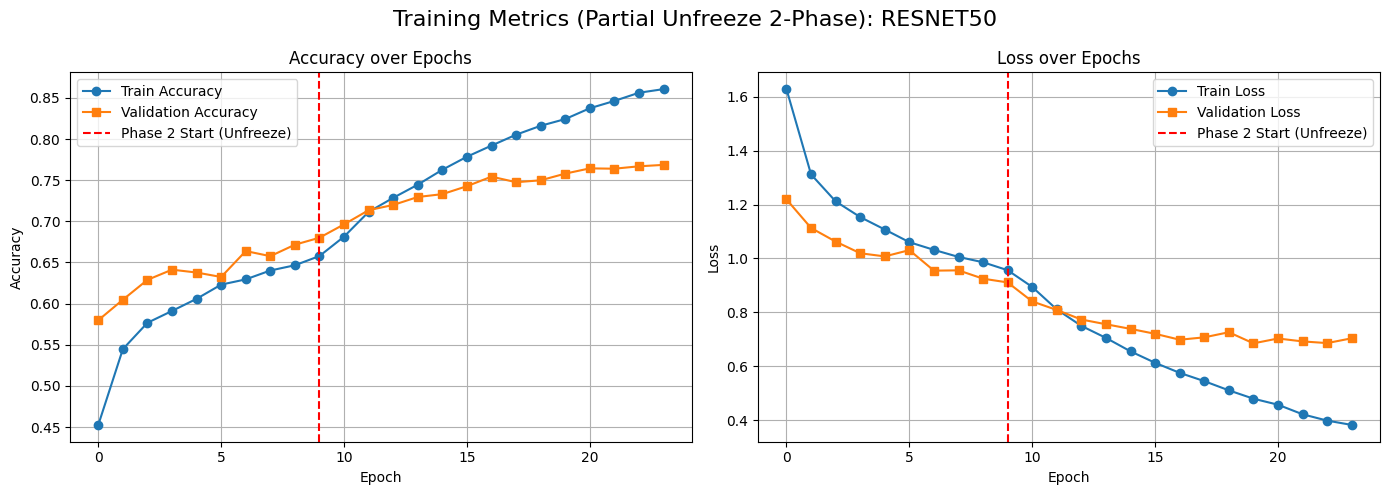

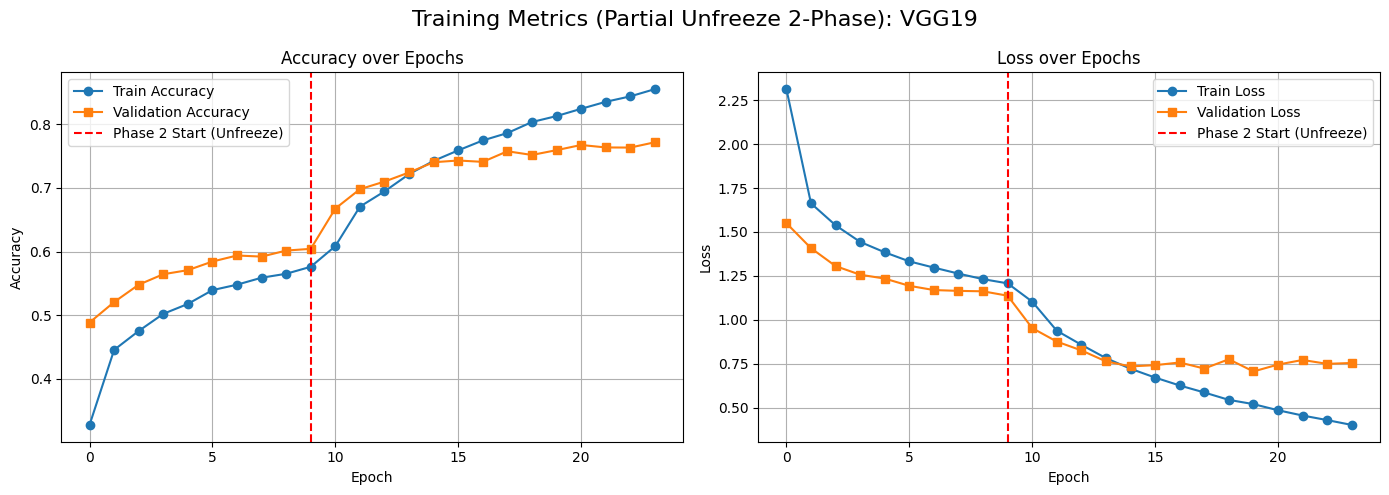

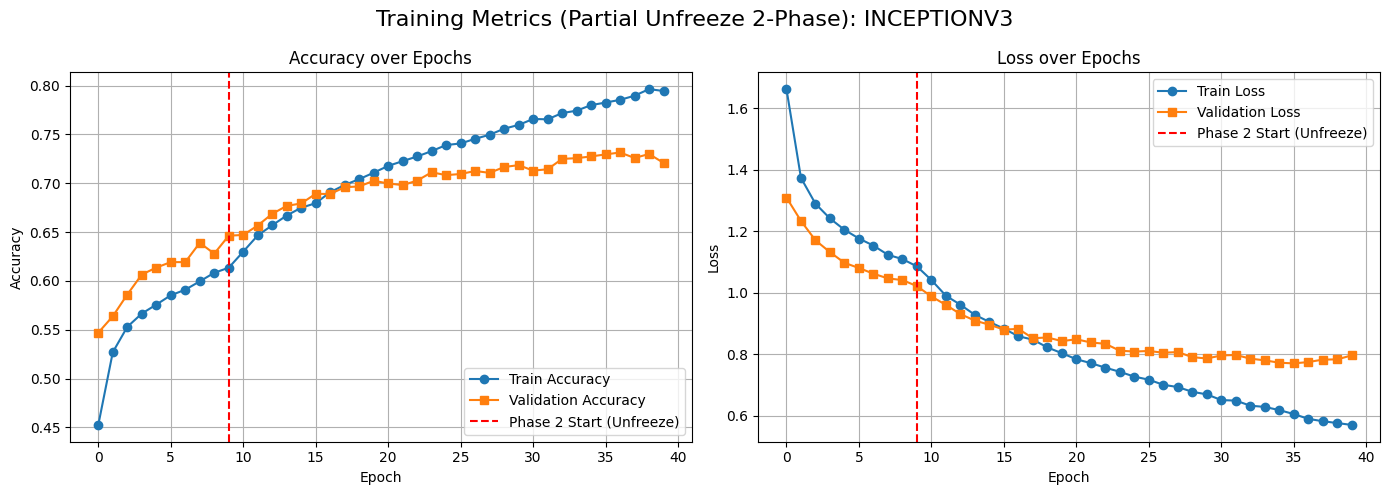

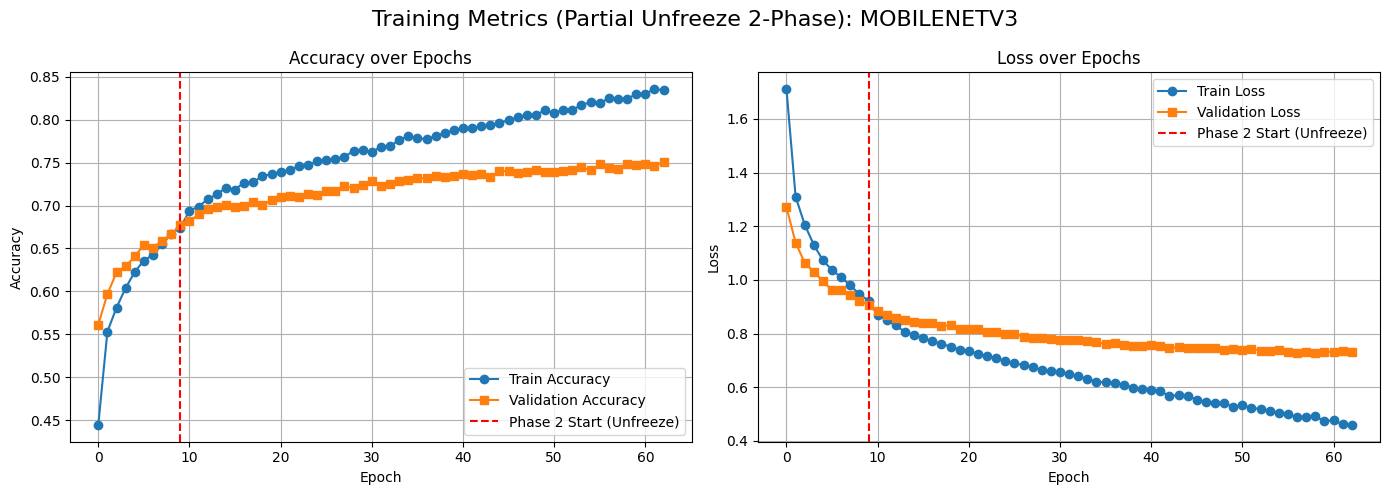

In [6]:
# ─────────────────────────────────────────────
for model_name in MODEL_CONFIGS.keys():
    log_p1 = os.path.join(LOG_DIR, f"{model_name}_p1_log.csv")
    log_p2 = os.path.join(LOG_DIR, f"{model_name}_p2_log.csv")
    
    if os.path.exists(log_p1) and os.path.exists(log_p2):
        df_p1 = pd.read_csv(log_p1)
        df_p2 = pd.read_csv(log_p2)
        
        # Gabungkan epoch untuk visualisasi kontinu
        df_p2['epoch'] = df_p2['epoch'] + df_p1['epoch'].max() + 1
        df_log = pd.concat([df_p1, df_p2], ignore_index=True)
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Training Metrics (Partial Unfreeze 2-Phase): {model_name.upper()}', fontsize=16)
        
        # Accuracy plot
        ax[0].plot(df_log['epoch'], df_log['accuracy'], label='Train Accuracy', marker='o')
        ax[0].plot(df_log['epoch'], df_log['val_accuracy'], label='Validation Accuracy', marker='s')
        ax[0].axvline(x=df_p1['epoch'].max(), color='red', linestyle='--', label='Phase 2 Start (Unfreeze)')
        ax[0].set_title('Accuracy over Epochs')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Accuracy')
        ax[0].legend()
        ax[0].grid(True)
        
        # Loss plot
        ax[1].plot(df_log['epoch'], df_log['loss'], label='Train Loss', marker='o')
        ax[1].plot(df_log['epoch'], df_log['val_loss'], label='Validation Loss', marker='s')
        ax[1].axvline(x=df_p1['epoch'].max(), color='red', linestyle='--', label='Phase 2 Start (Unfreeze)')
        ax[1].set_title('Loss over Epochs')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Loss')
        ax[1].legend()
        ax[1].grid(True)
        
        plt.tight_layout()
        plt.show()